# Библиотеки

In [ ]:
import pandas as pd
import os
from pathlib import Path
from typing import Dict, List, Tuple
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

import random

import torch
from torch.utils.data import Dataset, DataLoader
from typing import Optional

import torch.nn as nn

import timm
import sys
import torch.nn.functional as F


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    ReduceLROnPlateau,
    StepLR,
    OneCycleLR,
)
from tqdm import tqdm
import time
from datetime import datetime


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    roc_auc_score,
    matthews_corrcoef,
)
import seaborn as sns
from PIL import Image

# Параметры

In [ ]:
# =============================================================================
# БАЗОВЫЕ ПУТИ
# =============================================================================
PROJECT_ROOT = Path("/kaggle/working/")
DATA_DIR_OUT = Path("/kaggle/input/datasets/antineutrinoneutrino/my-lovely-dataset")
RAW_DATA_DIR = DATA_DIR_OUT / "raw"
PROCESSED_DATA_DIR = DATA_DIR_OUT / "mappings"
SPLIT_DATA_DIR = DATA_DIR_OUT / "splitted_data"
RESULTS_DIR = PROJECT_ROOT / "results"
LOG_DIR = RESULTS_DIR / "logs"
MODELS_DIR = PROJECT_ROOT / "models"
CHECKPOINT_DIR = MODELS_DIR / "checkpoints_model"
EXPORT_DIR = MODELS_DIR / "export"
DEPLOYMENT_DIR = MODELS_DIR / "deployment"
ONNX_DIR = EXPORT_DIR / "onnx"
TORCHSCRIPT_DIR = EXPORT_DIR / "torchscript"
PACKAGE_DIR = EXPORT_DIR / "package"
ARTIST_METADATA_CSV = Path(
    "/kaggle/input/datasets/ikarus777/best-artworks-of-all-time/artists.csv"
)

# =============================================================================
# РАЗДЕЛЕНИЕ ВЫБОРКИ
# =============================================================================
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_SEED = 42

# =============================================================================
# ПРЕДОБРАБОТКА И ЗАГРУЗКА ДАННЫХ
# =============================================================================
IMG_SIZE = 224
IMAGE_NET_MEAN = [0.485, 0.456, 0.406]
IMAGE_NET_STD = [0.229, 0.224, 0.225]

BATCH_SIZE = 16
NUM_WORKERS = 4
PIN_MEMORY = True
TEST_BATCH_SIZE = 32
TEST_NUM_WORKERS = 4

# =============================================================================
# АРХИТЕКТУРЫ МОДЕЛЕЙ
# =============================================================================
HEAD_DROPOUT = 0
CNN_ARCH = "efficientnet_b0"
TRANSFORMER_ARCH = "swin_tiny_patch4_window7_224"
EMBEDDING_DIM = 96  # длина одного патча
HYBRID_TYPES = ["sequential", "parallel"]
HYBRID_TYPE = HYBRID_TYPES[1]

# =============================================================================
# ОБУЧЕНИЕ И ОПТИМИЗАЦИЯ
# =============================================================================
TOTAL_EPOCHS = 50
LR_WARMUP_EPOCHS = 5
OPTIMIZER = "adam"
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MOMENTUM = 0.9
LR_SCHEDULER = "cosine"  # варианты: 'cosine', 'step', 'plateau'
LABEL_SMOOTHING = 0.1
TASK_WEIGHTS = {"artist": 6.0, "style": 1.0, "era": 1.0}
USE_CLASS_WEIGHTS = True
USE_AMP = True  # Автоматическая смешанная точность для ускорения

# =============================================================================
# РАННЯЯ ОСТАНОВКА И ЛОГИРОВАНИЕ
# =============================================================================
EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 0.001

TENSORBOARD_ENABLED = True
CSV_LOG_ENABLED = True

SAVE_BEST_MODEL = True
SAVE_LAST_MODEL = True
SAVE_EVERY_N_EPOCHS = 5

# =============================================================================
# ОЦЕНКА И СРАВНЕНИЕ АРХИТЕКТУР
# =============================================================================
COMPARE_ARCHITECTURES = True
ARCHITECTURES_TO_COMPARE = ["sequential", "parallel"]

# =============================================================================
# ВИЗУАЛИЗАЦИЯ И ИНТЕРПРЕТАЦИЯ (Grad-CAM, Attention)
# =============================================================================
GRAD_CAM_ALPHA = 0.4
GRAD_CAM_TARGET_LAYER = None  # Автоматическое определение
GRAD_CAM_UPSAMPLE_METHOD = "bilinear"
CAM_COLORMAP = "jet"

ATTENTION_AGGREGATION = "mean"  # варианты: 'mean', 'max', 'sum'
ATTENTION_NORMALIZE = True
ATTENTION_ALPHA = 0.5
ATTENTION_COLORMAP = "viridis"

NUM_IMAGES_TO_VISUALIZE = 20
NUM_CORRECT_IMAGES = 10
NUM_INCORRECT_IMAGES = 10

VISUALIZATION_DIR = RESULTS_DIR / "visualization"
GRAD_CAM_DIR = VISUALIZATION_DIR / "grad_cam"
ATTENTION_DIR = VISUALIZATION_DIR / "attention_maps"
COMBINED_DIR = VISUALIZATION_DIR / "combined"
COMPARISON_DIR = VISUALIZATION_DIR / "architecture_comparison"

# =============================================================================
# ПАРАМЕТРЫ СОХРАНЕНИЯ И ЭКСПОРТА
# =============================================================================
DPI_FOR_PLOTS = 300
FIGSIZE = (12, 10)
# Объединены списки форматов из обеих ячеек
SAVE_FORMATS = ["png", "pdf", "csv", "json", "svg"]

EXPORT_ONNX = True
EXPORT_TORCHSCRIPT = True
EXPORT_PACKAGE = True

ONNX_OPSET_VERSION = 13
ONNX_DYNAMIC_AXES = True
ONNX_OPTIMIZE = True

TORCHSCRIPT_TRACE = True  # True = trace, False = script
TORCHSCRIPT_OPTIMIZE = True

INCLUDE_CONFIG = True
INCLUDE_TRANSFORMS = True
INCLUDE_CLASS_MAPPINGS = True
INCLUDE_INFERENCE_SCRIPT = True
CREATE_REQUIREMENTS = True

# =============================================================================
# МЕТАДАННЫЕ МОДЕЛИ И ВЫЧИСЛИТЕЛЬНОЕ УСТРОЙСТВО
# =============================================================================
MODEL_NAME = "ArtAttributionHybrid"
MODEL_VERSION = "1.0.0"
MODEL_AUTHOR = "Student Name"
MODEL_DESCRIPTION = "Гибридная нейросетевая модель для атрибуции произведений живописи"
MODEL_LICENSE = "MIT"

DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"
EXPORT_DEVICE = "cpu"  # 'cpu' для совместимости, 'cuda' для производительности

# Предварительный анализ

In [ ]:
artists = pd.read_csv(
    "/kaggle/input/datasets/ikarus777/best-artworks-of-all-time/artists.csv"
)

In [ ]:
def get_image_paths(data_dir: Path) -> Dict[str, List[Path]]:
    """
    Собирает пути ко всем изображениям, сгруппированные по художникам
    Возвращает словарь, где ключи - художники, а объекты - пути к его работам.

    """
    artist_images = {}  # художник - ключ; список путей к работам автора - значение

    for artist_folder in data_dir.iterdir():  # циклом проходимся по папкам
        if artist_folder.is_dir():
            artist_name = artist_folder.name  # извлечение имени папки

            images = []

            for img_path in (
                artist_folder.iterdir()
            ):  # проход по каждой картине, принадлежащей художнику
                images.append(img_path)

            artist_images[artist_name] = images

    return artist_images

In [ ]:
dict = get_image_paths(
    Path("/kaggle/input/datasets/ikarus777/best-artworks-of-all-time/images/images")
)

In [ ]:
def check_broken_images(image_paths: List[Path]) -> List[Path]:
    """
    Проверяет изображения на битые файлы и возращает список путей с битыми файлами

    """
    broken_images = []

    for img_path in image_paths:
        try:
            img = cv2.imread(str(img_path))  # загрузка изображения
            if (
                img is None or img.size == 0
            ):  # или файл не открылся, или открылся, но данных нет
                broken_images.append(img_path)
        except Exception as e:
            broken_images.append(img_path)

    return broken_images

In [7]:
print(dict.keys())
check_broken_images(dict["Alfred_Sisley"])

dict_keys(['Jackson_Pollock', 'Albrecht_Dürer', 'Alfred_Sisley', 'Jan_van_Eyck', 'Kazimir_Malevich', 'Sandro_Botticelli', 'Rembrandt', 'Vincent_van_Gogh', 'Raphael', 'Frida_Kahlo', 'Georges_Seurat', 'Edouard_Manet', 'Michelangelo', 'Salvador_Dali', 'Giotto_di_Bondone', 'Diego_Rivera', 'Peter_Paul_Rubens', 'William_Turner', 'Leonardo_da_Vinci', 'Piet_Mondrian', 'Vasiliy_Kandinskiy', 'Titian', 'Paul_Gauguin', 'Francisco_Goya', 'Edgar_Degas', 'Pablo_Picasso', 'Henri_Rousseau', 'Paul_Cezanne', 'Andy_Warhol', 'Mikhail_Vrubel', 'Diego_Velazquez', 'Hieronymus_Bosch', 'Eugene_Delacroix', 'Andrei_Rublev', 'Gustav_Klimt', 'Henri_Matisse', 'Gustave_Courbet', 'Caravaggio', 'Joan_Miro', 'Pierre-Auguste_Renoir', 'Rene_Magritte', 'Camille_Pissarro', 'Henri_de_Toulouse-Lautrec', 'El_Greco', 'Claude_Monet', 'Marc_Chagall', 'Paul_Klee', 'Edvard_Munch', 'Albrecht_Du╠êrer', 'Amedeo_Modigliani', 'Pieter_Bruegel'])


[]

In [8]:
DATA_DIR_OUT = "/kaggle/working/data"
if not os.path.isdir(DATA_DIR_OUT):
    os.mkdir(DATA_DIR_OUT)

In [ ]:
def analyze_dataset(data_dir: Path) -> pd.DataFrame:
    """
    Проводит развдочный анализ датасета по пути к директории с данными.

    """
    artist_images = get_image_paths(data_dir)

    stats = []
    all_images = []  # сбор кортежей (художник, путь к файлу)
    broken_files = []

    for artist, images in artist_images.items():
        broken = check_broken_images(images)
        if broken:
            broken_files.extend(broken)
            valid_images = [img for img in images if img not in broken]
        else:
            valid_images = images

        stats.append(
            {
                "artist": artist,
                "total_images": len(images),
                "valid_images": len(valid_images),
                "broken_images": len(broken),
            }
        )

        all_images.extend([(artist, img) for img in valid_images])

    df = pd.DataFrame(stats)
    df = df.sort_values("valid_images", ascending=False).reset_index(
        drop=True
    )  # по убыванию количества картин

    images_df = pd.DataFrame(all_images, columns=["artist", "image_path"])
    images_df.to_csv(
        DATA_DIR_OUT + "/all_images.csv", index=False, encoding="utf-8-sig"
    )

    return df


In [ ]:
df = analyze_dataset(
    Path("/kaggle/input/datasets/ikarus777/best-artworks-of-all-time/images/images")
)
df.tail()

Corrupt JPEG data: 10 extraneous bytes before marker 0xd9


,artist,total_images,valid_images,broken_images
46,Michelangelo,49,49,0
47,Paul_Cezanne,47,47,0
48,Georges_Seurat,43,43,0
49,Eugene_Delacroix,31,31,0
50,Jackson_Pollock,24,24,0


In [ ]:
def visualize_class_distribution(df: pd.DataFrame):
    """
    Визуализирует распределение картин по художникам.

    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Распределение количества изображений по художникам
    axes[0, 0].bar(range(len(df)), df["valid_images"])
    axes[0, 0].set_xlabel("Художник (индекс)")
    axes[0, 0].set_ylabel("Количество изображений")
    axes[0, 0].set_title("Распределение изображений по художникам")
    axes[0, 0].grid(alpha=0.3)

    # Гистограмма: как часто встречаются художники с определенным количеством изображений
    axes[0, 1].hist(df["valid_images"], bins=20, edgecolor="black")
    axes[0, 1].set_xlabel("Количество изображений")
    axes[0, 1].set_ylabel("Количество художников")
    axes[0, 1].set_title("Гистограмма распределения классов")
    axes[0, 1].grid(alpha=0.3)

    # Кумулятивное распределение (Понять, насколько датасет сконцентрирован: например, 80% данных могут принадлежать 20% художников)
    sorted_counts = df["valid_images"].sort_values().values
    cumulative = np.cumsum(sorted_counts) / np.sum(sorted_counts) * 100
    axes[1, 0].plot(range(len(cumulative)), cumulative)
    axes[1, 0].set_xlabel("Художник (отсортировано)")
    axes[1, 0].set_ylabel("Накопленный процент (%)")
    axes[1, 0].set_title("Кумулятивное распределение")
    axes[1, 0].grid(alpha=0.3)
    axes[1, 0].axhline(y=80, color="r", linestyle="--", label="80%")
    axes[1, 0].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def print_dataset_summary(df: pd.DataFrame):
    """
    Выводит сводную статистику по датасету в консоль.
    """
    print(f"Всего художников (классов): {len(df)}")
    print(f"Всего изображений: {df['valid_images'].sum()}")
    print(f"Всего битых файлов: {df['broken_images'].sum()}")
    print(
        f"Среднее количество изображений на художника: {df['valid_images'].mean():.1f}"
    )
    print(f"Медианное количество изображений: {df['valid_images'].median():.1f}")
    print(f"Минимум изображений у: {df['valid_images'].min()}")
    print(f"Максимум изображений у: {df['valid_images'].max()}")
    print(
        f"Дисбаланс классов составляет: {df['valid_images'].max() / df['valid_images'].min():.2f}"
    )

    # Топ-5 и_BOTTOM-5 художников
    print(" топ-5 художников по количеству работ:")
    for idx, row in df.head(5).iterrows():
        print(f"  {idx + 1}. {row['artist']}: {row['valid_images']} изображений")

    print("\n топ-5 художников с наименьшим количеством работ:")
    for idx, row in df.tail(5).iterrows():
        print(f"  {idx + 1}. {row['artist']}: {row['valid_images']} изображений")


Corrupt JPEG data: 10 extraneous bytes before marker 0xd9


Всего художников (классов): 51
Всего изображений: 8774
Всего битых файлов: 0
Среднее количество изображений на художника: 172.0
Медианное количество изображений: 126.0
Минимум изображений у: 24
Максимум изображений у: 877
Дисбаланс классов составляет: 36.54
 топ-5 художников по количеству работ:
  1. Vincent_van_Gogh: 877 изображений
  2. Edgar_Degas: 702 изображений
  3. Pablo_Picasso: 439 изображений
  4. Pierre-Auguste_Renoir: 336 изображений
  5. Albrecht_Du╠êrer: 328 изображений

 топ-5 художников с наименьшим количеством работ:
  47. Michelangelo: 49 изображений
  48. Paul_Cezanne: 47 изображений
  49. Georges_Seurat: 43 изображений
  50. Eugene_Delacroix: 31 изображений
  51. Jackson_Pollock: 24 изображений


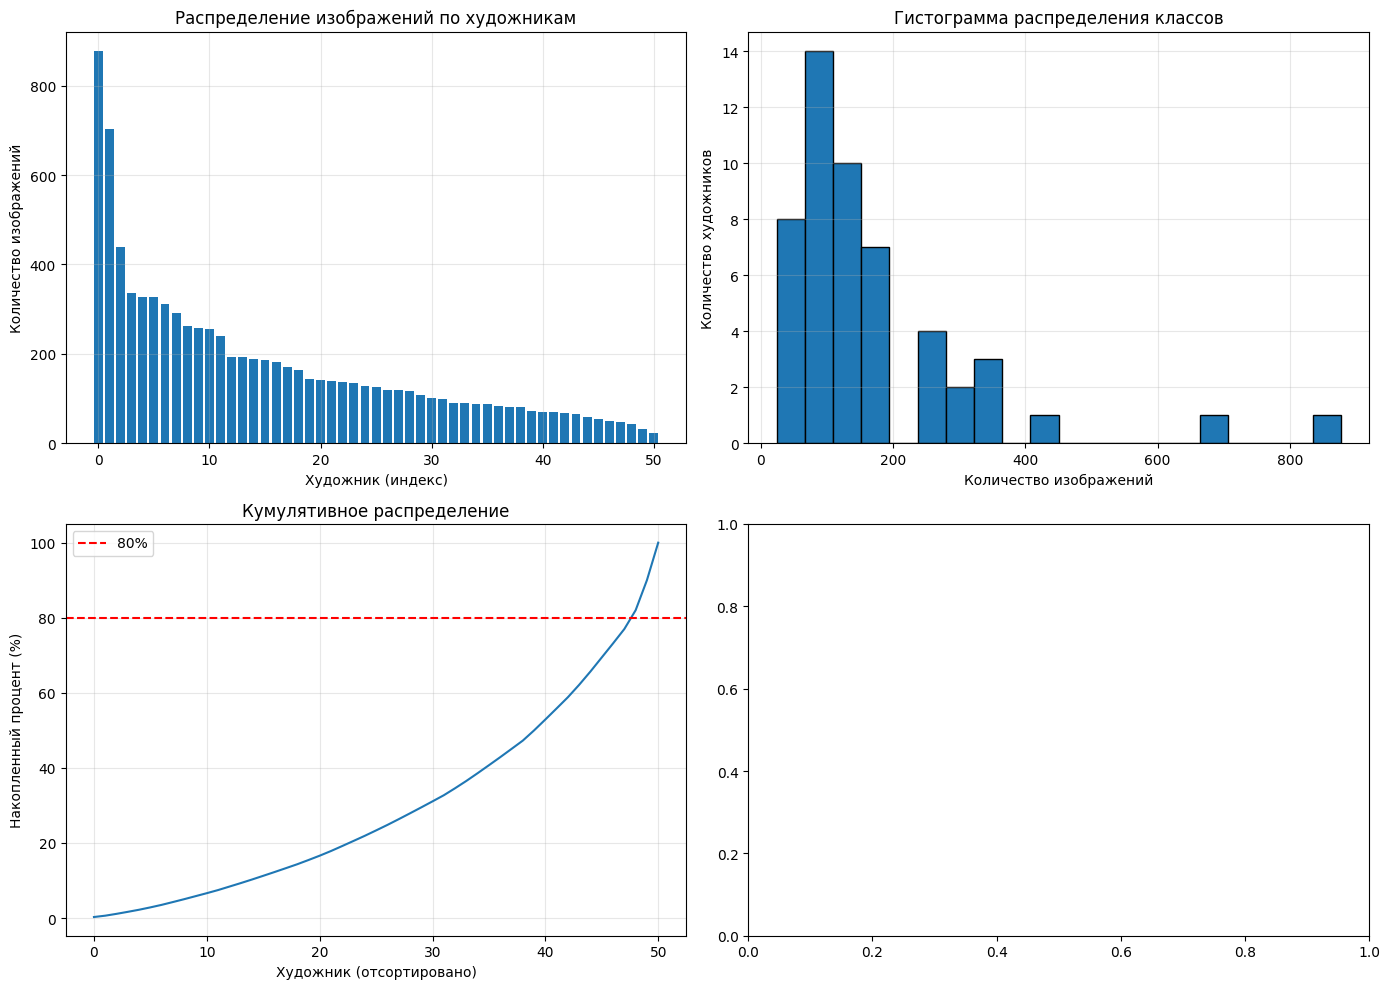

In [ ]:
df = analyze_dataset(
    Path("/kaggle/input/datasets/ikarus777/best-artworks-of-all-time/images/images")
)
print_dataset_summary(df)
visualize_class_distribution(df)

# Разделение выборки

In [ ]:
def stratified_split(
    images_df: pd.DataFrame,  # датасет: с колонками: художник и пути к его картинам
    train_size: float = TRAIN_RATIO,
    val_size: float = VAL_RATIO,
    test_size: float = TEST_RATIO,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Стратифицированное разделение данных на train/val/test.
    В каждой выборке будет изображение каждого художника в заданных пропорциях.

    """

    assert abs(train_size + val_size + test_size - 1.0) < 0.01, (
        "Сумма тренировочной, валидационной и тестововой выборок должна быть равна 1.0"
    )

    # Сначала разделяем на train и (val+test)
    train_df, temp_df = train_test_split(
        images_df,
        test_size=(val_size + test_size),
        stratify=images_df[
            "artist"
        ],  # чтобы в трейне, вале и тесте было одинаковое соотношение авторов
    )

    # Затем разделяем temp на val и test
    val_df, test_df = train_test_split(
        temp_df,
        test_size=test_size / (val_size + test_size),
        stratify=temp_df["artist"],
    )

    # нумерация с одного числа, чтобы индексы совпадали
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    return train_df, val_df, test_df

In [ ]:
def save_splits(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    output_dir: Path = Path(
        "/kaggle/working/data/splitted_data"
    ),  # путь для сохранения
):
    """
    Сохраняет разделения в CSV файлы.
    """
    output_dir.mkdir(
        parents=True, exist_ok=True
    )  # создание папки splitted_data с  возможностью добавить  вложенные папки

    train_df.to_csv(output_dir / "train.csv", index=False, encoding="utf-8-sig")
    val_df.to_csv(output_dir / "val.csv", index=False, encoding="utf-8-sig")
    test_df.to_csv(output_dir / "test.csv", index=False, encoding="utf-8-sig")

    print(f" Train: {len(train_df)} изображений сохранено в {output_dir / 'train.csv'}")
    print(f" Val: {len(val_df)} изображений сохранено в {output_dir / 'val.csv'}")
    print(f" Test: {len(test_df)} изображений сохранено в {output_dir / 'test.csv'}")


In [ ]:
def create_artist_mappings(
    train_df: pd.DataFrame, output_dir: Path = Path("/kaggle/working/data/mappings")
):
    artists = sorted(
        [str(name).strip().lower() for name in train_df["artist"].unique()]
    )

    artist2id = {artist: idx for idx, artist in enumerate(artists)}
    id2artist = {idx: artist for artist, idx in artist2id.items()}

    output_dir.mkdir(parents=True, exist_ok=True)
    with open(output_dir / "artist2id.json", "w", encoding="utf-8") as f:
        json.dump(artist2id, f, ensure_ascii=False, indent=2)
    with open(output_dir / "id2artist.json", "w", encoding="utf-8") as f:
        json.dump(id2artist, f, ensure_ascii=False, indent=2)

    return artist2id, id2artist


In [ ]:
def load_artist_metadata(csv_path: Path = ARTIST_METADATA_CSV) -> pd.DataFrame:
    """
    Загружает CSV с метаданными художников.

    Ожидаемые колонки:
    - id: Уникальный идентификатор
    - name: Имя художника (должно совпадать с именем папки)
    - years: Период жизни (например, "1884 - 1920")
    - genre: Стиль/стили (через запятую, например "Expressionism,Abstractionism")
    - nationality: Национальность
    - era: Эпоха (если есть отдельная колонка, иначе вычисляется из years)

    Returns:
        DataFrame с метаданными
    """
    df = pd.read_csv(csv_path)

    # Нормализация имён: удаление пробелов, приведение к нижнему регистру
    df["name_clean"] = df["name"]

    # Обработка колонки genre (стили)
    if "genre" in df.columns:
        df["styles"] = df["genre"].apply(
            parse_styles
        )  # к столбцу жанра мы используем функцию, написанную ниже

    # если есть колонка 'era', используем её
    # Иначе вычисляем эпоху из years
    if "era" not in df.columns and "years" in df.columns:
        df["era"] = df["years"].apply(extract_era_from_years)

    return df


def parse_styles(genre_str: str) -> List[str]:
    """
    Парсит строку со стилями, разделёнными запятой.

    Args:
        genre_str: Строка вида "Expressionism,Abstractionism"

    Returns:
        Список стилей: ["Expressionism", "Abstractionism"]
    """
    if pd.isna(genre_str) or genre_str == "":
        return ["Unknown"]

    styles = [s.strip() for s in str(genre_str).split(",")]
    return [s for s in styles if s]  # Удаление пустых строк


def extract_era_from_years(years_str: str) -> str:
    """
    Вычисляет эпоху из периода жизни художника.

    - 1400-1499: "15th_century"
    - 1500-1599: "16th_century"
    - 1600-1699: "17th_century"
    - 1700-1799: "18th_century"
    - 1800-1899: "19th_century"
    - 1900-1999: "20th_century"
    - 2000+: "21st_century"

    Args:
        years_str: Строка вида "1884 - 1920"

    Returns:
        Название эпохи
    """
    if pd.isna(years_str):
        return "Unknown"

    # Извлекаем год рождения
    try:
        birth_year = int(str(years_str).split("-")[0].strip())
    except:
        return "Unknown"

    # Простая классификация по векам
    if birth_year < 1500:
        return "15th_century"
    elif birth_year < 1600:
        return "16th_century"
    elif birth_year < 1700:
        return "17th_century"
    elif birth_year < 1800:
        return "18th_century"
    elif birth_year < 1900:
        return "19th_century"
    elif birth_year < 2000:
        return "20th_century"
    else:
        return "21st_century"


def create_era_and_style_mappings(
    metadata_df: pd.DataFrame,
    artist2id: Dict[str, int],
    save_dir: Path = PROCESSED_DATA_DIR,
) -> Tuple[Dict[str, Dict[str, int]], Dict[str, Dict[int, str]]]:
    """
    Создаёт маппинги классов для эпох и стилей.

    Args:
        metadata_df: DataFrame с метаданными
        artist2id: Существующий маппинг художник → ID
        save_dir: Директория для сохранения

    Returns:
        (style2id, era2id), (id2style, id2era)
    """
    # Стили
    all_styles = set()
    for styles in metadata_df["styles"]:
        all_styles.update(styles)

    style2id = {style: idx for idx, style in enumerate(sorted(all_styles))}
    id2style = {idx: style for style, idx in style2id.items()}

    # Эпохи
    all_eras = metadata_df["era"].dropna().unique()
    era2id = {era: idx for idx, era in enumerate(sorted(all_eras))}
    id2era = {idx: era for era, idx in era2id.items()}

    # Сохранение маппингов
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "style2id.json", "w", encoding="utf-8") as f:
        json.dump(style2id, f, ensure_ascii=False, indent=2)

    with open(save_dir / "id2style.json", "w", encoding="utf-8") as f:
        json.dump(id2style, f, ensure_ascii=False, indent=2)

    with open(save_dir / "era2id.json", "w", encoding="utf-8") as f:
        json.dump(era2id, f, ensure_ascii=False, indent=2)

    with open(save_dir / "id2era.json", "w", encoding="utf-8") as f:
        json.dump(id2era, f, ensure_ascii=False, indent=2)

    print(f"Создано {len(style2id)} классов стилей")
    print(f"Создано {len(era2id)} классов эпох")

    return (style2id, era2id), (id2style, id2era)


def create_artist_to_labels_mapping(
    metadata_df: pd.DataFrame,
    artist2id: Dict[str, int],
    style2id: Dict[str, int],
    era2id: Dict[str, int],
    random_seed: int = RANDOM_SEED,
) -> Dict[int, Dict[str, any]]:
    """
    Создаёт маппинг artist_id → {style_ids: [...], era_id: int}.

    Для художников с несколькими стилями сохраняем все ID стилей
    (выбор случайного стиля будет происходить в Dataset при загрузке).

    Args:
        metadata_df: DataFrame с метаданными
        artist2id: Маппинг художник → ID
        style2id: Маппинг стиль → ID
        era2id: Маппинг эпоха → ID

    Returns:
        Словарь {artist_id: {'style_ids': [...], 'era_id': int}}
    """
    np.random.seed(random_seed)

    mapping = {}

    for _, row in metadata_df.iterrows():
        artist_name = row["name_clean"]

        # Пропускаем художников, которых нет в нашем датасете
        if artist_name not in artist2id:
            continue

        artist_id = artist2id[artist_name]

        # Одна Эпоха на художника
        era = row.get("era", "Unknown")
        era_id = era2id.get(era, era2id.get("Unknown", 0))

        # Стили (их может быть несколько)
        styles = row.get("styles", ["Unknown"])
        style_ids = [style2id.get(s, style2id.get("Unknown", 0)) for s in styles]

        mapping[artist_id] = {"style_ids": style_ids, "era_id": era_id}

    return mapping

# Аугментация и предобработка

In [ ]:
def get_train_transforms():
    """
    Трансформации для обучающей выборки.
    """
    return A.Compose(
        [
            # Масштабирование изображение, чтобы наибольшая сторона стала 224+32 с сохранением исходных пропорций
            A.LongestMaxSize(
                max_size=IMG_SIZE + 32, p=1.0
            ),  # 32 запас для следующего вырезания
            # Случайная обрезка с сохранением важной области
            # Вырезает кусок изображения(80-100%). Приводим к заданному размеру после обрезки (size)
            A.RandomResizedCrop(
                size=(IMG_SIZE, IMG_SIZE),  # размер изображения после обрезки
                scale=(0.8, 1.0),  # Сохраняем 80-100% изображения
                ratio=(
                    0.95,
                    1.05,
                ),  # Минимальное искажение пропорций. То насколько могут разниться соотношения.
                p=1.0,  # вероятность применения трансформации
            ),
            # Геометрические аугментации
            A.HorizontalFlip(p=0.5),
            # A.VerticalFlip(p=0.2),
            # A.RandomRotate90(p=0.3),
            # Лёгкие геометрические искажения
            A.ShiftScaleRotate(
                shift_limit=0.05,  # лимит сдвига: сдиг изображения по вертикали и горизонтали на 5 процентов
                scale_limit=0.03,  # лимит масштаба: изменение (уменьшение/увеличение) масштаба на 5 проценотов
                rotate_limit=10,  # лимит поворота: поворот изображения на случайный угол от -10 до 10
                border_mode=1,  # Режим заполнения границ: чем заполнять пустые области после трансформации(1 - дублирование краёв)
                p=0.5,
            ),
            # Нормализация (приведение к распределению имаджнет)и конвертация в тензор
            A.Normalize(mean=IMAGE_NET_MEAN, std=IMAGE_NET_STD, max_pixel_value=255.0),
            ToTensorV2(),  # конвертация формата HWC -> CHW (стандарт пайторч).
        ],
        p=1.0,
    )


In [ ]:
def get_val_transforms():
    """
    Трансформации для валидационной выборки.
    Только Center Crop без аугментаций.
    """
    return A.Compose(
        [
            # Масштабирование
            A.LongestMaxSize(max_size=IMG_SIZE + 32, p=1.0),
            # Паддинг для того, чтобы размер не стал меньше 224
            A.PadIfNeeded(
                min_height=IMG_SIZE,
                min_width=IMG_SIZE,
                border_mode=cv2.BORDER_REPLICATE,
                p=1.0,
            ),
            # Центральная обрезка
            A.CenterCrop(height=IMG_SIZE, width=IMG_SIZE, p=1.0),
            # Нормализация и конвертация в тензор
            A.Normalize(mean=IMAGE_NET_MEAN, std=IMAGE_NET_STD, max_pixel_value=255.0),
            ToTensorV2(),
        ],
        p=1.0,
    )


In [13]:
def get_test_transforms():
    """
    Трансформации для тестовой выборки.
    """
    return get_val_transforms()

In [14]:
def get_inference_transforms():
    """
    Трансформации для картин не из датасета.
    """
    return get_val_transforms()


# Создание загрузчика данных

In [ ]:
"""
Кастомный Dataset для загрузки изображений с тремя метками:
- artist (художник)
- style (стиль — случайный выбор из списка художника)
- era (эпоха — фиксированная для художника)
"""


class ArtDataset(Dataset):
    def __init__(
        self,
        csv_path: Path,
        artist2id: Dict[str, int],
        artist_labels_mapping: Dict[int, Dict[str, any]],
        transforms=None,
        return_path: bool = False,
        random_seed: int = RANDOM_SEED,
    ):
        self.data = pd.read_csv(csv_path)
        self.artist2id = artist2id
        self.artist_labels_mapping = artist_labels_mapping
        self.transforms = transforms
        self.return_path = return_path
        self.random = random.Random(random_seed)

        # фильтрация: оставляем только известные художники
        original_len = len(self.data)
        self.data["artist_clean"] = self.data["artist"].str.strip().str.lower()

        normalized_mapping = {k.strip().lower(): v for k, v in self.artist2id.items()}
        self.artist2id = (
            normalized_mapping  # перезаписываем, чтобы __getitem__ тоже работал
        )

        self.data = self.data[
            self.data["artist_clean"].isin(self.artist2id.keys())
        ].copy()
        filtered_len = len(self.data)
        if filtered_len < original_len:
            print(
                f"Отфильтровано {original_len - filtered_len} изображений с неизвестными художниками"
            )

        if "artist_clean" in self.data.columns:
            self.data = self.data.drop(columns=["artist_clean"])

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(
        self, idx: int
    ) -> Tuple[torch.Tensor, Dict[str, int], Optional[str]]:
        row = self.data.iloc[idx]
        img_path = Path(row["image_path"])
        artist_name = row["artist"].strip().lower()

        # Загрузка изображения
        image = cv2.imread(str(img_path))
        if image is None:
            raise ValueError(f"Не удалось загрузить изображение: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Применение трансформаций
        if self.transforms:
            augmented = self.transforms(image=image)
            image = augmented["image"]

        # Получение меток (теперь художник гарантированно есть в artist2id)
        artist_id = self.artist2id[artist_name]

        # Получаем метки стиля и эпохи из маппинга
        labels_info = self.artist_labels_mapping.get(
            artist_id, {"style_ids": [0], "era_id": 0}
        )

        era_id = labels_info["era_id"]
        style_ids = labels_info["style_ids"]
        style_id = self.random.choice(style_ids) if style_ids else 0

        labels = {"artist": artist_id, "style": style_id, "era": era_id}

        if self.return_path:
            return image, labels, str(img_path)
        else:
            return image, labels


def load_all_mappings(
    processed_dir: Path = PROCESSED_DATA_DIR,
    metadata_csv: Path = ARTIST_METADATA_CSV,
    random_seed: int = RANDOM_SEED,
) -> Tuple[Dict, Dict, Dict, Dict]:
    """
    Загружает все необходимые маппинги для Dataset.

    Returns:
        artist2id, style2id, era2id, artist_labels_mapping
    """
    # Загрузка artist2id
    with open(processed_dir / "artist2id.json", "r", encoding="utf-8") as f:
        artist2id = json.load(f)

    # Загрузка style2id и era2id (если есть)
    style2id_path = processed_dir / "style2id.json"
    era2id_path = processed_dir / "era2id.json"

    if style2id_path.exists():
        with open(style2id_path, "r", encoding="utf-8") as f:
            style2id = json.load(f)
    else:
        style2id = {}

    if era2id_path.exists():
        with open(era2id_path, "r", encoding="utf-8") as f:
            era2id = json.load(f)
    else:
        era2id = {}

    # Если маппинги стилей/эпох не созданы, создаём их
    if not style2id or not era2id:
        metadata_df = load_artist_metadata(metadata_csv)
        (style2id, era2id), _ = create_class_mappings(
            metadata_df, artist2id, processed_dir
        )

    # Создание маппинга artist → labels
    metadata_df = load_artist_metadata(metadata_csv)
    artist_labels_mapping = create_artist_to_labels_mapping(
        metadata_df, artist2id, style2id, era2id, random_seed
    )

    return artist2id, style2id, era2id, artist_labels_mapping


In [ ]:
def create_dataloaders(
    data_dir: Path,
    artist2id: Dict[str, int],
    artist_labels_mapping: Dict[int, Dict[str, any]],
    batch_size: int = BATCH_SIZE,
    num_workers: int = NUM_WORKERS,
    pin_memory: bool = PIN_MEMORY,
    random_seed: int = RANDOM_SEED,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Создаёт DataLoaders для train/val/test с тремя метками.
    """
    # Загрузка трансформаций
    train_transforms = get_train_transforms()
    val_transforms = get_val_transforms()
    test_transforms = get_test_transforms()

    # Создание датасетов
    train_dataset = ArtDataset(
        csv_path=data_dir / "train.csv",
        artist2id=artist2id,
        artist_labels_mapping=artist_labels_mapping,
        transforms=train_transforms,
        random_seed=random_seed,
    )

    val_dataset = ArtDataset(
        csv_path=data_dir / "val.csv",
        artist2id=artist2id,
        artist_labels_mapping=artist_labels_mapping,
        transforms=val_transforms,
        random_seed=random_seed,
    )

    test_dataset = ArtDataset(
        csv_path=data_dir / "test.csv",
        artist2id=artist2id,
        artist_labels_mapping=artist_labels_mapping,
        transforms=test_transforms,
        return_path=True,
        random_seed=random_seed,
    )

    # Collate function для обработки словарей меток
    def collate_fn(batch):
        """
        Collate function для обработки батчей с многозадачными метками.

        Args:
            batch: Список кортежей [(image, labels), ...] или [(image, labels, path), ...]

        Returns:
            (images_tensor, labels_dict) или (images_tensor, labels_dict, paths_list)
        """
        # Проверяем, есть ли пути в элементах батча
        # batch[0] — это первый элемент: (image, labels) или (image, labels, path)
        if len(batch[0]) == 3:
            # С путями: (image, labels, path)
            images, labels_list, paths = zip(*batch)
            has_paths = True
        else:
            # Без путей: (image, labels)
            images, labels_list = zip(*batch)
            paths = None
            has_paths = False

        # Stack изображений в один тензор [B, C, H, W]
        images = torch.stack(images)

        # Конвертация списка словарей меток в словарь тензоров
        # labels_list: [{'artist': 0, 'style': 2, 'era': 1}, {...}, ...]
        labels = {
            "artist": torch.LongTensor([l["artist"] for l in labels_list]),
            "style": torch.LongTensor([l["style"] for l in labels_list]),
            "era": torch.LongTensor([l["era"] for l in labels_list]),
        }

        # Возврат с путями или без
        if has_paths:
            return images, labels, paths
        else:
            return images, labels

    # Создание DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=True,
        collate_fn=collate_fn,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        collate_fn=collate_fn,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        collate_fn=collate_fn,
    )

    return train_loader, val_loader, test_loader


In [ ]:
def calculate_class_weights(
    artist2id: Dict[str, int],
    style2id: Dict[str, int],
    era2id: Dict[str, int],
    train_csv: Path,
    artist_labels_mapping: Dict[int, Dict[str, any]],
) -> Dict[str, torch.Tensor]:
    """
    Вычисляет веса классов для всех трёх задач по Формуле (2.1).

    ω_c = N_total / (C * N_c)

    Returns:
        Словарь весов: {'artist': ..., 'style': ..., 'era': ...}
    """
    df = pd.read_csv(train_csv)

    weights = {}

    for task, id_mapping in [
        ("artist", artist2id),
        ("style", style2id),
        ("era", era2id),
    ]:
        N_total = len(df)
        C = len(id_mapping)

        # Подсчёт количества примеров на класс
        class_counts = {}

        for _, row in df.iterrows():
            artist_name = row["artist"].strip().lower()
            artist_id = artist2id.get(artist_name)

            if artist_id is None or artist_id not in artist_labels_mapping:
                continue

            if task == "artist":
                class_id = artist_id
            elif task == "style":
                # Для стиля: учитываем все стили художника пропорционально
                style_ids = artist_labels_mapping[artist_id]["style_ids"]
                weight_per_style = 1.0 / len(style_ids) if style_ids else 1.0
                for sid in style_ids:
                    class_counts[sid] = class_counts.get(sid, 0) + weight_per_style
                continue  # Пропускаем стандартный подсчёт
            else:  # era
                class_id = artist_labels_mapping[artist_id]["era_id"]

            class_counts[class_id] = class_counts.get(class_id, 0) + 1

        # Вычисление весов
        task_weights = [0.0] * len(id_mapping)
        for class_name, class_id in id_mapping.items():
            N_c = max(class_counts.get(class_id, 1), 1)  # Защита от 0
            task_weights[class_id] = N_total / (C * N_c)

        weights[task] = torch.FloatTensor(task_weights)

    return weights

# Классифицирующие головы

вся н.с. - эмбеддер, который возвращает векторное представление. Это вектрное представление является одномерным вектором разной длины(размерности для разных нейронных сетей. В одной будет один и тот же размер). Задача головы - превратить вектор в логит (вектор размера 1000 превратился в вектор размера 10). Делается это так: вектор 1000 умножается на матрицу 1000*10 и получается вектор размера 10. Дальше софтмакс.

Матрица состоит из обучающихся весов. Помним про смещение

In [ ]:
class ClassificationHead(nn.Module):  # свой слой на основании уже имеющегося
    """
    Классифицирующая голова для одной задачи.
    """

    def __init__(self, input_dim: int, num_classes: int, dropout: float = HEAD_DROPOUT):
        """
        Args:
            input_dim: Размерность входного вектора признаков
            num_classes: Количество классов для данной задачи
            dropout: Коэффициент Dropout для регуляризации
        """
        super().__init__()

        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(
                input_dim, num_classes
            ),  # меняет размерность вектора (матрица 10*3, а не 10*30 с помощью матрицы весов в линейном слое) до размерности, соответсвующей количеству классов (размерность input_dim -> num_clasess)
        )

    def forward(
        self, x: torch.Tensor
    ) -> torch.Tensor:  # 1 батч (матрица из картинок) подается на вход в голову и применяется последовательность дропаута и линейности
        """
        Args:
            x: Тензор признаков [B, input_dim]

        Returns:
            Логиты классов [B, num_classes]
        """
        return self.head(x)

In [ ]:
class MultiTaskHeads(nn.Module):
    """
    Набор из трёх классифицирующих голов для многозадачного обучения.
    """

    def __init__(
        self,
        input_dim: int,
        num_artists: int,
        num_styles: int,
        num_eras: int,
        dropout: float = HEAD_DROPOUT,
    ):
        """
        Args:
            input_dim: Размерность входного вектора признаков
            num_artists: Количество классов художников
            num_styles: Количество классов стилей
            num_eras: Количество классов эпох
        """
        super().__init__()  # вызываем init у nn.Module, чтобы был создан слой с низкоуровневыми вещами

        self.artist_head = ClassificationHead(input_dim, num_artists, dropout)
        self.style_head = ClassificationHead(input_dim, num_styles, dropout)
        self.era_head = ClassificationHead(input_dim, num_eras, dropout)

    def forward(self, x: torch.Tensor) -> Dict:  # объясняем, что объекту надо делать
        """
        Args:
            x: Тензор признаков [B, input_dim]

        Returns:
            Словарь с логитами для каждой задачи
        """
        return {
            "artist": self.artist_head(x),
            "style": self.style_head(x),
            "era": self.era_head(x),
        }

    def predict(self, x: torch.Tensor) -> Dict:  # если нужны не логиты, а вероятности
        """
        Возвращает предсказания с применением Softmax.

        Args:
            x: Тензор признаков [B, input_dim]

        Returns:
            Словарь с вероятностями для каждой задачи
        """
        logits = self.forward(x)

        return {
            "artist": torch.softmax(logits["artist"], dim=1),
            "style": torch.softmax(logits["style"], dim=1),
            "era": torch.softmax(logits["era"], dim=1),
        }

# Классы гибридных моделей

In [ ]:
class SequentialHybridModel(nn.Module):
    """
    Последовательная гибридная архитектура:
    Изображение → EfficientNet → Карты признаков → Swin Transformer → Классификаторы
    """

    def __init__(
        self,
        num_artists: int,
        num_styles: int,
        num_eras: int,
        cnn_arch: str = CNN_ARCH,
        transformer_arch: str = TRANSFORMER_ARCH,
        pretrained: bool = True,
        embedding_dim: int = None,
    ):
        super().__init__()

        self.cnn = timm.create_model(
            cnn_arch, pretrained=pretrained, features_only=True, out_indices=(4,)
        )
        cnn_out_channels = self.cnn.feature_info.channels()[-1]

        self.cnn_to_transformer_adapter = nn.Sequential(
            nn.Conv2d(cnn_out_channels, 3, kernel_size=1),
            nn.BatchNorm2d(3),
            nn.ReLU(inplace=True),
        )

        self.transformer = timm.create_model(
            transformer_arch, pretrained=pretrained, num_classes=0
        )

        #  Автоматически берём размерность выхода Swin
        target_dim = (
            embedding_dim
            if embedding_dim is not None
            else self.transformer.num_features
        )

        self.heads = MultiTaskHeads(
            input_dim=target_dim,
            num_artists=num_artists,
            num_styles=num_styles,
            num_eras=num_eras,
        )

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        # CNN -> Адаптер -> Upscale
        cnn_features = self.cnn(x)[-1]
        adapted = self.cnn_to_transformer_adapter(cnn_features)
        x_up = F.interpolate(
            adapted, size=(224, 224), mode="bilinear", align_corners=False
        )

        # Swin Transformer
        transformer_features = self.transformer.forward_features(x_up)

        #  ПУЛИНГ (автоматически определяет layout)
        # Если C оказалось не на 2-й позиции (channels_last), меняем оси
        if (
            transformer_features.dim() == 4
            and transformer_features.shape[1] != self.transformer.num_features
        ):
            transformer_features = transformer_features.permute(0, 3, 1, 2).contiguous()

        # Теперь точно [B, C, H, W] -> усредняем только по пространству
        features = transformer_features.mean(dim=(2, 3))  # [B, 768]

        # 4. Классификация
        return self.heads(features)

    def get_feature_maps(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        cnn_features = self.cnn(x)[-1]
        adapted = self.cnn_to_transformer_adapter(cnn_features)
        return {
            "cnn_features": cnn_features.detach(),
            "adapted_features": adapted.detach(),
        }

    def freeze_cnn(self, freeze: bool = True):
        for param in self.cnn.parameters():
            param.requires_grad = not freeze

    def freeze_transformer(self, freeze: bool = True):
        for param in self.transformer.parameters():
            param.requires_grad = not freeze

In [ ]:
class ParallelHybridModel(nn.Module):
    """
    Параллельная гибридная архитектура:
    Изображение → [EfficientNet || Swin Transformer] → Конкатенация → Классификаторы

    """

    def __init__(
        self,
        num_artists: int,
        num_styles: int,
        num_eras: int,
        cnn_arch: str = CNN_ARCH,
        transformer_arch: str = TRANSFORMER_ARCH,
        pretrained: bool = True,
        num_for_increase: float = 1.0,  # По умолчанию 1.0, т.к. увеличение обычно нужно после конкатенации
    ):
        super().__init__()

        self.cnn = timm.create_model(
            cnn_arch, pretrained=pretrained, features_only=False, num_classes=0
        )
        cnn_out_dim = self.cnn.num_features  # 1280 для EfficientNet-B0

        self.transformer = timm.create_model(
            transformer_arch, pretrained=pretrained, features_only=False, num_classes=0
        )
        transformer_out_dim = (
            self.transformer.num_features
        )  # 768 для Swin-Tiny (НЕ embed_dim!)

        # Реальная размерность после конкатенации

        combined_dim = cnn_out_dim + transformer_out_dim  # 1280 + 768 = 2048

        # Если нужно увеличить/уменьшить размерность ПЕРЕД головами:
        fusion_in_dim = int(combined_dim * num_for_increase)

        self.feature_fusion = nn.Sequential(
            nn.Linear(combined_dim, fusion_in_dim),
            nn.BatchNorm1d(fusion_in_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(fusion_in_dim, EMBEDDING_DIM),
            nn.BatchNorm1d(EMBEDDING_DIM),
            nn.ReLU(inplace=True),
        )

        self.heads = MultiTaskHeads(
            input_dim=EMBEDDING_DIM,
            num_artists=num_artists,
            num_styles=num_styles,
            num_eras=num_eras,
        )

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        # 1. Извлечение признаков
        cnn_feat = self.cnn.forward_features(x)
        swin_feat = self.transformer.forward_features(x)

        # 2. Приведение к формату [B, C, H, W] (если модель вернула [B, H, W, C])
        if cnn_feat.dim() == 4 and cnn_feat.shape[1] < cnn_feat.shape[-1]:
            cnn_feat = cnn_feat.permute(0, 3, 1, 2).contiguous()
        if swin_feat.dim() == 4 and swin_feat.shape[1] < swin_feat.shape[-1]:
            swin_feat = swin_feat.permute(0, 3, 1, 2).contiguous()

        # 3. Глобальный пулинг по пространству (H, W)
        # .mean(dim=(2, 3)) эквивалентен adaptive_avg_pool2d(..., 1) + squeeze, но быстрее
        cnn_pool = cnn_feat.mean(dim=(2, 3))  # [B, 1280]
        swin_pool = swin_feat.mean(dim=(2, 3))  # [B, 768]

        # 4. Конкатенация и Fusion
        combined = torch.cat([cnn_pool, swin_pool], dim=1)  # [B, 2048]
        fused = self.feature_fusion(combined)

        return self.heads(fused)

    def get_feature_maps(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Возвращает промежуточные карты признаков для визуализации.
        """
        cnn_features = self.cnn.forward_features(x)
        transformer_features = self.transformer.forward_features(x)

        return {
            "cnn_features": cnn_features.detach(),
            "transformer_features": transformer_features.detach(),
        }

    def freeze_cnn(self, freeze: bool = True):
        """Замораживает/размораживает веса CNN."""
        for param in self.cnn.parameters():
            param.requires_grad = not freeze

    def freeze_transformer(self, freeze: bool = True):
        """Замораживает/размораживает веса трансформера."""
        for param in self.transformer.parameters():
            param.requires_grad = not freeze


In [ ]:
def create_model(
    model_type: str,
    num_artists: int,
    num_styles: int,
    num_eras: int,
    pretrained: bool = True,
) -> nn.Module:
    """
    Фабрика для создания моделей.

    Args:
        model_type: 'sequential' или 'parallel'
        num_artists: Количество классов художников
        num_styles: Количество классов стилей
        num_eras: Количество классов эпох
        pretrained: Использовать ли предобученные веса

    Returns:
        Модель PyTorch
    """
    if model_type == "sequential":
        return SequentialHybridModel(
            num_artists=num_artists,
            num_styles=num_styles,
            num_eras=num_eras,
            pretrained=pretrained,
        )
    elif model_type == "parallel":
        return ParallelHybridModel(
            num_artists=num_artists,
            num_styles=num_styles,
            num_eras=num_eras,
            pretrained=pretrained,
        )
    else:
        raise ValueError(
            f"Неизвестный тип модели: {model_type}. Используйте 'sequential' или 'parallel'."
        )

In [ ]:
"""
Вспомогательные функции для работы с моделями.
"""


def count_parameters(model: nn.Module) -> Dict[str, int]:
    """
    Подсчитывает количество параметров модели.

    Args:
        model: PyTorch модель

    Returns:
        Словарь с количеством параметров (всего, обучаемых, по компонентам)
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Подсчёт по компонентам
    components = {}

    for name, module in model.named_children():
        comp_params = sum(p.numel() for p in module.parameters())
        comp_trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
        components[name] = {"total": comp_params, "trainable": comp_trainable}

    return {
        "total": total_params,
        "trainable": trainable_params,
        "non_trainable": total_params - trainable_params,
        "components": components,
    }


def save_model_checkpoint(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    val_loss: float,
    save_path: Path,
    extra_info: Dict = None,
):
    """
    Сохраняет чекпоинт (набор весов модели, которые мы обучили) модели.

    Args:
        model: Модель PyTorch
        optimizer: Оптимизатор
        epoch: Номер эпохи
        val_loss: Валидационная потеря
        save_path: Путь для сохранения
        extra_info: Дополнительная информация (метрики, конфигурация)
    """
    save_path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_loss": val_loss,
        "extra_info": extra_info or {},
    }

    torch.save(checkpoint, save_path)
    print(f"Чекпоинт сохранён: {save_path}")


def load_model_checkpoint(
    model: nn.Module, optimizer: torch.optim.Optimizer, load_path: Path
) -> Tuple[int, float, Dict]:
    """
    Загружает чекпоинт модели.

    Args:
        model: Модель PyTorch
        optimizer: Оптимизатор
        load_path: Путь к чекпоинту

    Returns:
        epoch, val_loss, extra_info
    """
    checkpoint = torch.load(load_path, map_location="cpu")

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    print(f"Чекпоинт загружен: {load_path}")
    print(f"Эпоха: {checkpoint['epoch']}, Val Loss: {checkpoint['val_loss']:.4f}")

    return checkpoint["epoch"], checkpoint["val_loss"], checkpoint.get("extra_info", {})


def get_model_size_mb(model: nn.Module) -> float:
    """
    Вычисляет размер модели в мегабайтах.

    Args:
        model: PyTorch модель

    Returns:
        Размер в МБ
    """
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()

    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    return (param_size + buffer_size) / 1024 / 1024


def freeze_layers_by_epoch(
    model: nn.Module,
    current_epoch: int,
    freeze_cnn_until: int = 0,
    freeze_transformer_until: int = 0,
):
    """
    Управляет заморозкой слоёв в зависимости от эпохи.

    Args:
        model: Гибридная модель
        current_epoch: Текущая эпоха обучения
        freeze_cnn_until: Замораживать CNN до этой эпохи
        freeze_transformer_until: Замораживать трансформер до этой эпохи
    """
    if hasattr(model, "freeze_cnn"):
        if current_epoch < freeze_cnn_until:
            model.freeze_cnn(freeze=True)
        else:
            model.freeze_cnn(freeze=False)

    if hasattr(model, "freeze_transformer"):
        if current_epoch < freeze_transformer_until:
            model.freeze_transformer(freeze=True)
        else:
            model.freeze_transformer(freeze=False)

In [ ]:
def print_model_summary(
    model: nn.Module, input_size: Tuple[int, int, int, int] = (1, 3, 224, 224)
):
    """
    Выводит сводную информацию о модели.

    Args:
        model: PyTorch модель
        input_size: Размер входного тензора [B, C, H, W]
    """

    print("СВОДКА ПО АРХИТЕКТУРЕ МОДЕЛИ")

    # Тип модели
    print(f"Тип модели: {model.__class__.__name__}")

    # Параметры
    params = count_parameters(model)
    print(f"\n Параметры:")
    print(f"  Всего: {params['total']:,}")
    print(f"  Обучаемые: {params['trainable']:,}")
    print(f"  Замороженные: {params['non_trainable']:,}")
    print(f"  Доля обучаемых: {params['trainable'] / params['total'] * 100:.1f}%")

    # Параметры по компонентам
    print(f"\n Параметры по компонентам:")
    for comp_name, comp_params in params["components"].items():
        print(f"  {comp_name}:")
        print(f"    Всего: {comp_params['total']:,}")
        print(f"    Обучаемые: {comp_params['trainable']:,}")

    # Тестовый проход
    print(f"\n Тестовый проход (input_size={input_size}):")
    model.eval()
    device = next(model.parameters()).device
    dummy_input = torch.randn(input_size).to(device)

    try:
        with torch.no_grad():
            output = model(dummy_input)

        print(f"  Выход:")
        for task, tensor in output.items():
            print(f"    {task}: {tensor.shape}")

        print("\n Тестовый проход успешен!")

    except Exception as e:
        print(f"\n Ошибка при тестовом проходе: {e}")

In [ ]:
"""
Скрипт для тестирования гибридных архитектур моделей.
"""


def load_num_classes():
    """
    Загружает количество классов из сохранённых маппингов.
    """
    with open(PROCESSED_DATA_DIR / "artist2id.json", "r", encoding="utf-8") as f:
        artist2id = json.load(f)

    # Для стиля и эпохи используем заглушки (будут заменены при реальной разметке)
    num_artists = len(artist2id)
    num_styles = int(max(10, num_artists // 3))  # Заглушка
    num_eras = int(max(5, num_artists // 5))  # Заглушка

    return num_artists, num_styles, num_eras


def test_sequential_model():
    """
    Тестирует последовательную архитектуру.
    """

    print("Тестирование ПОСЛЕДОВАТЕЛЬНОЙ архитектуры")

    num_artists, num_styles, num_eras = load_num_classes()

    model = SequentialHybridModel(
        num_artists=num_artists,
        num_styles=num_styles,
        num_eras=num_eras,
        pretrained=False,  # False для быстрого тестирования
    )

    print_model_summary(model)

    # Проверка размера
    size_mb = get_model_size_mb(model)
    print(f" Размер модели: {size_mb:.2f} МБ")

    # Проверка forward pass
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    dummy_input = torch.randn(2, 3, 224, 224).to(device)

    with torch.no_grad():
        output = model(dummy_input)

    print(f"\n Выход модели:")
    for task, tensor in output.items():
        print(f"   {task}: {tensor.shape}")

    # Проверка извлечения признаков
    feature_maps = model.get_feature_maps(dummy_input)
    print(f"\n Карты признаков:")
    for name, tensor in feature_maps.items():
        print(f"   {name}: {tensor.shape}")

    return model


def test_parallel_model():
    """
    Тестирует параллельную архитектуру.
    """

    print(" Тестирование ПАРАЛЛЕЛЬНОЙ архитектуры")

    num_artists, num_styles, num_eras = load_num_classes()

    model = ParallelHybridModel(
        num_artists=num_artists,
        num_styles=num_styles,
        num_eras=num_eras,
        pretrained=False,  # False для быстрого тестирования
    )

    print_model_summary(model)

    # Проверка размера
    size_mb = get_model_size_mb(model)
    print(f" Размер модели: {size_mb:.2f} МБ")

    # Проверка forward pass
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    dummy_input = torch.randn(2, 3, 224, 224).to(device)

    with torch.no_grad():
        output = model(dummy_input)

    print(f"\n Выход модели:")
    for task, tensor in output.items():
        print(f"   {task}: {tensor.shape}")

    # Проверка извлечения признаков
    feature_maps = model.get_feature_maps(dummy_input)
    print(f"\n Карты признаков:")
    for name, tensor in feature_maps.items():
        print(f"   {name}: {tensor.shape}")

    return model


def compare_architectures():
    """
    Сравнивает две архитектуры по параметрам и размеру.
    """

    print(" СРАВНЕНИЕ АРХИТЕКТУР")

    num_artists, num_styles, num_eras = load_num_classes()

    seq_model = SequentialHybridModel(
        num_artists=num_artists,
        num_styles=num_styles,
        num_eras=num_eras,
        pretrained=False,
    )

    par_model = ParallelHybridModel(
        num_artists=num_artists,
        num_styles=num_styles,
        num_eras=num_eras,
        pretrained=False,
    )

    seq_params = count_parameters(seq_model)
    par_params = count_parameters(par_model)

    seq_size = get_model_size_mb(seq_model)
    par_size = get_model_size_mb(par_model)

    print(f"\n{'Параметр':<25} | {'Sequential':<15} | {'Parallel':<15}")
    print(
        f"{'Всего параметров':<25} | {seq_params['total']:>12,} | {par_params['total']:>12,}"
    )
    print(
        f"{'Обучаемые параметры':<25} | {seq_params['trainable']:>12,} | {par_params['trainable']:>12,}"
    )
    print(f"{'Размер модели (МБ)':<25} | {seq_size:>12.2f} | {par_size:>12.2f}")

    # Рекомендация
    print(f"\n Рекомендация:")
    if seq_params["total"] < par_params["total"]:
        print(
            f"   Последовательная архитектура легче на {(par_params['total'] - seq_params['total']) / seq_params['total'] * 100:.1f}%"
        )
    else:
        print(
            f"   Параллельная архитектура легче на {(seq_params['total'] - par_params['total']) / par_params['total'] * 100:.1f}%"
        )


def test_model_factory():
    """
    Тестирует фабрику создания моделей.
    """
    print(" Тестирование ФАБРИКИ моделей")

    num_artists, num_styles, num_eras = load_num_classes()

    # Тест последовательной
    seq_model = create_model(
        model_type="sequential",
        num_artists=num_artists,
        num_styles=num_styles,
        num_eras=num_eras,
        pretrained=False,
    )
    print(f" Создана последовательная модель: {type(seq_model).__name__}")

    # Тест параллельной
    par_model = create_model(
        model_type="parallel",
        num_artists=num_artists,
        num_styles=num_styles,
        num_eras=num_eras,
        pretrained=False,
    )
    print(f" Создана параллельная модель: {type(par_model).__name__}")

    # Тест ошибки
    try:
        create_model(
            model_type="invalid",
            num_artists=num_artists,
            num_styles=num_styles,
            num_eras=num_eras,
            pretrained=False,
        )
    except ValueError as e:
        print(f" Корректно обработана ошибка: {e}")


def main():
    """
    Запускает все тесты моделей.
    """

    # Проверка наличия данных
    if not (PROCESSED_DATA_DIR / "artist2id.json").exists():
        print(" Файл artist2id.json не найден!")
        return

    # Тест фабрики
    test_model_factory()

    # Тест последовательной модели
    seq_model = test_sequential_model()

    # Тест параллельной модели
    par_model = test_parallel_model()

    # Сравнение архитектур
    compare_architectures()

    # Сохранение тестовой модели
    MODELS_DIR.mkdir(parents=True, exist_ok=True)

    test_save_path = MODELS_DIR / "test_model.pth"
    torch.save(seq_model.state_dict(), test_save_path)
    print(f" Тестовая модель сохранена: {test_save_path}")

In [26]:
main()

 Тестирование ФАБРИКИ моделей
 Создана последовательная модель: SequentialHybridModel
 Создана параллельная модель: ParallelHybridModel
 Корректно обработана ошибка: Неизвестный тип модели: invalid. Используйте 'sequential' или 'parallel'.
Тестирование ПОСЛЕДОВАТЕЛЬНОЙ архитектуры
СВОДКА ПО АРХИТЕКТУРЕ МОДЕЛИ
Тип модели: SequentialHybridModel

 Параметры:
  Всего: 31,175,693
  Обучаемые: 31,175,693
  Замороженные: 0
  Доля обучаемых: 100.0%

 Параметры по компонентам:
  cnn:
    Всего: 3,595,388
    Обучаемые: 3,595,388
  cnn_to_transformer_adapter:
    Всего: 969
    Обучаемые: 969
  transformer:
    Всего: 27,519,354
    Обучаемые: 27,519,354
  heads:
    Всего: 59,982
    Обучаемые: 59,982

 Тестовый проход (input_size=(1, 3, 224, 224)):
  Выход:
    artist: torch.Size([1, 51])
    style: torch.Size([1, 17])
    era: torch.Size([1, 10])

 Тестовый проход успешен!
 Размер модели: 120.14 МБ

 Выход модели:
   artist: torch.Size([2, 51])
   style: torch.Size([2, 17])
   era: torch.Size

# Настройка процесса обучения

In [ ]:
"""
Функции потерь для многозадачного обучения.
Взвешенная категориальная кросс-энтропия с учётом дисбаланса классов.
"""


"""
Функция потерь для многозадачного обучения с тремя классификациями.
"""

import torch
import torch.nn as nn
from typing import Dict, Optional


class MultiTaskLoss(nn.Module):
    """Взвешенная сумма кросс-энтропий для трёх задач"""

    def __init__(
        self,
        task_weights: Dict[str, float] = None,
        class_weights: Optional[Dict[str, torch.Tensor]] = None,
        label_smoothing: float = 0.0,
    ):
        super().__init__()
        self.task_weights = task_weights or TASK_WEIGHTS
        self.label_smoothing = label_smoothing

        # Регистрируем веса как буферы модуля, чтобы .to(device) автоматически перемещал их
        if class_weights:
            for task, weights in class_weights.items():
                if weights is not None:
                    self.register_buffer(f"{task}_class_weights", weights)

    def forward(
        self, outputs: Dict[str, torch.Tensor], targets: Dict[str, torch.Tensor]
    ) -> Dict[str, torch.Tensor]:
        losses = {}
        total_loss = 0.0

        for task in ["artist", "style", "era"]:
            if task in outputs and task in targets:
                # Берём вес, если он задан, и явно переносим на устройство входных логитов
                class_weight = getattr(self, f"{task}_class_weights", None)
                if class_weight is not None:
                    class_weight = class_weight.to(outputs[task].device)

                # Функциональный вызов корректно работает с динамическими весами и label_smoothing
                loss = F.cross_entropy(
                    outputs[task],
                    targets[task],
                    weight=class_weight,
                    label_smoothing=self.label_smoothing,
                )
                losses[task] = loss * self.task_weights.get(task, 1.0)
                total_loss += losses[task]

        losses["total"] = total_loss
        return losses


class FocalLoss(
    nn.Module
):  # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!11
    """
    Focal Loss для работы с сильным дисбалансом классов.
    Альтернатива взвешенной кросс-энтропии.
    """

    def __init__(self, alpha: float = 1.0, gamma: float = 2.0):
        """
        Args:
            alpha: Вес для балансировки классов
            gamma: Параметр фокусировки на сложных примерах
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = nn.CrossEntropyLoss(reduction="none")(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

In [ ]:
"""
Метрики для оценки качества классификации.
Accuracy, F1-score, Confusion Matrix для каждой задачи.
"""


class MultiTaskMetrics:
    """
    Вычисление метрик для многозадачной классификации.
    """

    def __init__(self, num_classes: Dict[str, int]):
        """
        Args:
            num_classes: Количество классов для каждой задачи
        """
        self.num_classes = num_classes
        self.reset()

    def reset(self):
        """Сбрасывает все накопленные предсказания и метки."""
        self.predictions = {"artist": [], "style": [], "era": []}
        self.targets = {"artist": [], "style": [], "era": []}
        self.probabilities = {"artist": [], "style": [], "era": []}

    def update(
        self, outputs: Dict[str, torch.Tensor], targets: Dict[str, torch.Tensor]
    ):
        """
        Добавляет новые предсказания и метки.

        Args:
            outputs: Словарь логитов или вероятностей
            targets: Словарь истинных меток
        """
        for task in ["artist", "style", "era"]:
            if task not in outputs or task not in targets:
                continue

            # Получаем предсказания (argmax для логитов/вероятностей)
            if outputs[task].dim() == 2:
                preds = outputs[task].argmax(dim=1).cpu().numpy()
            else:
                preds = outputs[task].cpu().numpy()

            self.predictions[task].append(preds)
            self.targets[task].append(targets[task].cpu().numpy())

            # Сохраняем вероятности для анализа
            if outputs[task].dim() == 2:
                probs = torch.softmax(outputs[task], dim=1).detach().cpu().numpy()
                self.probabilities[task].append(probs)

    def compute(self) -> Dict[str, Dict[str, float]]:
        """
        Вычисляет все метрики.

        Returns:
            Словарь метрик для каждой задачи
        """
        metrics = {}

        for task in ["artist", "style", "era"]:
            if not self.predictions[task]:
                continue

            y_pred = np.concatenate(self.predictions[task])
            y_true = np.concatenate(self.targets[task])

            # Accuracy
            acc = accuracy_score(y_true, y_pred)

            # F1-score (macro)
            f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

            # F1-score (weighted)
            f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

            metrics[task] = {
                "accuracy": acc,
                "f1_macro": f1_macro,
                "f1_weighted": f1_weighted,
                "num_samples": len(y_true),
            }

        return metrics

    def get_confusion_matrices(self) -> Dict[str, np.ndarray]:
        """
        Возвращает матрицы ошибок для каждой задачи.

        Returns:
            Словарь с матрицами ошибок
        """
        matrices = {}

        for task in ["artist", "style", "era"]:
            if not self.predictions[task]:
                continue

            y_pred = np.concatenate(self.predictions[task])
            y_true = np.concatenate(self.targets[task])

            matrices[task] = confusion_matrix(y_true, y_pred)

        return matrices

    def get_classification_report(
        self, task: str, class_names: List[str] = None
    ) -> str:
        """
        Возвращает текстовый отчёт по классификации для задачи.

        Args:
            task: Название задачи ('artist', 'style', 'era')
            class_names: Имена классов для отображения

        Returns:
            Текстовый отчёт sklearn
        """
        if not self.predictions[task]:
            return ""

        y_pred = np.concatenate(self.predictions[task])
        y_true = np.concatenate(self.targets[task])

        target_names = (
            class_names
            if class_names
            else [f"Class_{i}" for i in range(self.num_classes[task])]
        )

        return classification_report(
            y_true, y_pred, target_names=target_names, zero_division=0
        )

    def save_results(self, save_path: str):
        """
        Сохраняет результаты в CSV.

        Args:
            save_path: Путь для сохранения
        """
        metrics = self.compute()

        rows = []
        for task, task_metrics in metrics.items():
            rows.append(
                {
                    "task": task,
                    "accuracy": task_metrics["accuracy"],
                    "f1_macro": task_metrics["f1_macro"],
                    "f1_weighted": task_metrics["f1_weighted"],
                    "num_samples": task_metrics["num_samples"],
                }
            )

        df = pd.DataFrame(rows)
        df.to_csv(save_path, index=False)
        print(f"Метрики сохранены в {save_path}")

In [ ]:
"""
Планировщики скорости обучения (Learning Rate Schedulers).
"""


class WarmupScheduler:
    """
    Обёртка для добавления warmup к любому планировщику.
    """

    def __init__(
        self, optimizer, base_scheduler, warmup_epochs: int = LR_WARMUP_EPOCHS
    ):
        self.optimizer = optimizer
        self.base_scheduler = base_scheduler
        self.warmup_epochs = warmup_epochs
        self.current_epoch = 0
        self.base_lrs = [group["lr"] for group in optimizer.param_groups]

    def step(self):
        self.current_epoch += 1

        if self.current_epoch <= self.warmup_epochs:
            # Linear warmup
            progress = self.current_epoch / self.warmup_epochs
            for i, group in enumerate(self.optimizer.param_groups):
                group["lr"] = self.base_lrs[i] * progress
        else:
            # Основной планировщик
            self.base_scheduler.step()

    def get_last_lr(self):
        return [group["lr"] for group in self.optimizer.param_groups]


def create_scheduler(
    optimizer: torch.optim.Optimizer,
    scheduler_type: str = "cosine",
    total_epochs: int = TOTAL_EPOCHS,
    warmup_epochs: int = LR_WARMUP_EPOCHS,
):
    """
    Фабрика для создания планировщиков.

    Args:
        optimizer: Оптимизатор PyTorch
        scheduler_type: Тип планировщика ('cosine', 'step', 'plateau')
        total_epochs: Общее количество эпох
        warmup_epochs: Количество эпох warmup

    Returns:
        Планировщик скорости обучения
    """
    if scheduler_type == "cosine":
        base_scheduler = CosineAnnealingLR(
            optimizer, T_max=total_epochs - warmup_epochs, eta_min=1e-6
        )
    elif scheduler_type == "step":
        base_scheduler = StepLR(optimizer, step_size=total_epochs // 3, gamma=0.1)
    elif scheduler_type == "plateau":
        base_scheduler = ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5, verbose=True
        )
    else:
        raise ValueError(f"Неизвестный тип планировщика: {scheduler_type}")

    # Оборачиваем в warmup
    scheduler = WarmupScheduler(optimizer, base_scheduler, warmup_epochs)

    return scheduler

In [ ]:
"""
Ранняя остановка обучения для предотвращения переобучения.
"""


class EarlyStopping:
    """
    Ранняя остановка при отсутствии улучшения валидационной метрики.
    """

    def __init__(
        self,
        patience: int = EARLY_STOPPING_PATIENCE,
        min_delta: float = EARLY_STOPPING_MIN_DELTA,
        mode: str = "min",
        verbose: bool = True,
    ):
        """
        Args:
            patience: Количество эпох без улучшения перед остановкой
            min_delta: Минимальное изменение для считания улучшением
            mode: 'min' для потерь, 'max' для метрик качества
            verbose: Выводить ли сообщения
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.verbose = verbose

        self.counter = 0
        self.best_value = None
        self.early_stop = False

    def __call__(self, value: float) -> bool:
        """
        Проверяет условие остановки.

        Args:
            value: Текущее значение метрики (loss или accuracy)

        Returns:
            True если нужно остановить обучение
        """
        if self.best_value is None:
            self.best_value = value
            return False

        # Определяем было ли улучшение
        if self.mode == "min":
            improved = value < self.best_value - self.min_delta
        else:  # mode == 'max'
            improved = value > self.best_value + self.min_delta

        if improved:
            self.best_value = value
            self.counter = 0
            if self.verbose:
                print(f"Улучшение: {value:.4f}")
        else:
            self.counter += 1
            if self.verbose:
                print(f"Нет улучшения: {self.counter}/{self.patience}")

            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"Ранняя остановка после {self.counter} эпох без улучшений")

        return self.early_stop

    def reset(self):
        """Сбрасывает состояние для нового запуска."""
        self.counter = 0
        self.best_value = None
        self.early_stop = False

In [ ]:
"""
Основной класс для обучения гибридной модели с многозадачным обучением.
"""


class Trainer:
    """
    Класс для обучения многозадачной гибридной модели.
    Поддерживает три задачи классификации: artist, style, era.
    """

    def __init__(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        optimizer: torch.optim.Optimizer,
        criterion: Optional[nn.Module] = None,
        device: Optional[str] = None,
        use_amp: bool = USE_AMP,
    ):
        """
        Args:
            model: Модель для обучения
            train_loader: DataLoader для обучения
            val_loader: DataLoader для валидации
            optimizer: Оптимизатор
            criterion: Функция потерь (MultiTaskLoss). Если None, создаётся автоматически.
            device: Устройство ('cuda' или 'cpu')
            use_amp: Использовать ли смешанную точность
        """
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer

        # Устройство
        self.device = torch.device(
            device or ("cuda" if torch.cuda.is_available() else "cpu")
        )
        self.model.to(self.device)

        # Функция потерь
        if criterion is None:
            self.criterion = MultiTaskLoss(
                task_weights=TASK_WEIGHTS, class_weights=None, label_smoothing=0.1
            )
        else:
            self.criterion = criterion

        self.criterion.to(self.device)

        # Метрики
        num_classes = {
            "artist": model.heads.artist_head.head[-1].out_features,
            "style": model.heads.style_head.head[-1].out_features,
            "era": model.heads.era_head.head[-1].out_features,
        }
        self.train_metrics = MultiTaskMetrics(num_classes)
        self.val_metrics = MultiTaskMetrics(num_classes)

        # Смешанная точность
        self.use_amp = use_amp and self.device.type == "cuda"
        self.scaler = torch.amp.GradScaler("cuda") if self.use_amp else None

        # Логгер
        # self.logger: Optional[TrainingLogger] = None

    def train_epoch(self, epoch: int) -> Tuple[float, Dict]:
        """
        Одна эпоха обучения.

        Args:
            epoch: Номер эпохи (0-based)

        Returns:
            (average_loss, metrics_dict)
        """
        self.model.train()
        self.train_metrics.reset()

        total_loss = 0.0
        num_batches = 0

        progress_bar = tqdm(self.train_loader, desc=f"Epoch {epoch + 1} [Train]")

        for batch_idx, (images, labels) in enumerate(progress_bar):
            images = images.to(self.device)

            # labels — это словарь: {'artist': tensor, 'style': tensor, 'era': tensor}
            targets = {
                "artist": labels["artist"].to(self.device),
                "style": labels["style"].to(self.device),
                "era": labels["era"].to(self.device),
            }

            # Zero gradients
            self.optimizer.zero_grad()

            # Forward pass
            if self.use_amp:
                with torch.cuda.amp.autocast():
                    outputs = self.model(images)
                    losses = self.criterion(outputs, targets)

                # Backward pass с AMP
                self.scaler.scale(losses["total"]).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                outputs = self.model(images)
                losses = self.criterion(outputs, targets)
                losses["total"].backward()
                self.optimizer.step()

            # Обновление метрик для каждой задачи
            for task in ["artist", "style", "era"]:
                self.train_metrics.update(
                    outputs={task: outputs[task]}, targets={task: targets[task]}
                )

            # Статистика
            total_loss += losses["total"].item()
            num_batches += 1

            # Обновление прогресс-бара
            progress_bar.set_postfix(
                {
                    "loss": f"{losses['total'].item():.4f}",
                    "lr": f"{self.optimizer.param_groups[0]['lr']:.2e}",
                }
            )

        avg_loss = total_loss / num_batches if num_batches > 0 else float("inf")
        metrics = self.train_metrics.compute()

        return avg_loss, metrics

    @torch.no_grad()
    def validate_epoch(self, epoch: int) -> Tuple[float, Dict]:
        """
        Одна эпоха валидации (без градиентов).

        Args:
            epoch: Номер эпохи (0-based)

        Returns:
            (average_loss, metrics_dict)
        """
        self.model.eval()
        self.val_metrics.reset()

        total_loss = 0.0
        num_batches = 0

        progress_bar = tqdm(self.val_loader, desc=f"Epoch {epoch + 1} [Val]")

        for images, labels in progress_bar:
            images = images.to(self.device)
            targets = {
                "artist": labels["artist"].to(self.device),
                "style": labels["style"].to(self.device),
                "era": labels["era"].to(self.device),
            }

            # Forward pass
            if self.use_amp:
                with torch.cuda.amp.autocast():
                    outputs = self.model(images)
                    losses = self.criterion(outputs, targets)
            else:
                outputs = self.model(images)
                losses = self.criterion(outputs, targets)

            # Обновление метрик
            for task in ["artist", "style", "era"]:
                self.val_metrics.update(
                    outputs={task: outputs[task]}, targets={task: targets[task]}
                )

            # Статистика
            total_loss += losses["total"].item()
            num_batches += 1

            progress_bar.set_postfix({"loss": f"{losses['total'].item():.4f}"})

        avg_loss = total_loss / num_batches if num_batches > 0 else float("inf")
        metrics = self.val_metrics.compute()

        return avg_loss, metrics

    def fit(
        self,
        total_epochs: int = TOTAL_EPOCHS,
        scheduler=None,
        early_stopping: Optional[EarlyStopping] = None,
        experiment_name: Optional[str] = None,
        freeze_cnn_until: int = 0,
        freeze_transformer_until: int = 0,
    ) -> float:
        """
        Полный цикл обучения модели.

        Args:
            total_epochs: Общее количество эпох
            scheduler: Планировщик скорости обучения
            early_stopping: Стратегия ранней остановки
            experiment_name: Имя эксперимента для логирования
            freeze_cnn_until: Замораживать CNN до этой эпохи
            freeze_transformer_until: Замораживать трансформер до этой эпохи

        Returns:
            Лучшая валидационная потеря
        """
        # Инициализация логгера
        # if experiment_name:
        # self.logger = TrainingLogger(experiment_name=experiment_name)

        # Early stopping по умолчанию
        if early_stopping is None:
            early_stopping = EarlyStopping(mode="min", patience=10, verbose=True)

        # Отслеживание лучшей модели
        best_val_loss = float("inf")
        best_model_state = None

        print(f"Устройство: {self.device}")
        print(f"Эпох: {total_epochs}")
        print(f"Смешанная точность (AMP): {self.use_amp}")
        print(f"Задачи: artist, style, era")

        for epoch in range(total_epochs):
            epoch_start = time.time()

            # Управление заморозкой слоёв (transfer learning)
            freeze_layers_by_epoch(
                self.model, epoch, freeze_cnn_until, freeze_transformer_until
            )

            # Обучение
            train_loss, train_metrics = self.train_epoch(epoch)

            # Валидация
            val_loss, val_metrics = self.validate_epoch(epoch)

            epoch_time = time.time() - epoch_start

            # Планировщик скорости обучения
            if scheduler is not None:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(val_loss)
                else:
                    scheduler.step()

            # Логирование
            # if self.logger:
            #   current_lr = self.optimizer.param_groups[0]['lr']
            #  self.logger.log_epoch(
            #     epoch=epoch,
            #    train_loss=train_loss,
            ##   val_loss=val_loss,
            # train_metrics=train_metrics,
            # val_metrics=val_metrics,
            # learning_rate=current_lr,
            # epoch_time=epoch_time
            # )

            # Вывод результатов эпохи
            print(f"\n Epoch {epoch + 1}/{total_epochs} ({epoch_time:.1f}s)")
            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Val Loss:   {val_loss:.4f}")
            for task in ["artist", "style", "era"]:
                if task in val_metrics:
                    acc = val_metrics[task].get("accuracy", 0)
                    f1 = val_metrics[task].get("f1_macro", 0)
                    print(f"  Val {task:8s} — Acc: {acc:.4f}, F1: {f1:.4f}")

            # Сохранение лучшей модели
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {
                    k: v.cpu().clone() for k, v in self.model.state_dict().items()
                }
                print(f" Новая лучшая модель! Val Loss: {best_val_loss:.4f}")

            # Ранняя остановка
            if early_stopping(val_loss):
                print("\n Ранняя остановка обучения")
                break

        # Загрузка лучшей модели
        if SAVE_BEST_MODEL and best_model_state is not None:
            self.model.load_state_dict(best_model_state)
            print("\n Лучшая модель загружена в память")

        # Сохранение финального чекпоинта
        if SAVE_LAST_MODEL:
            CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            save_path = CHECKPOINT_DIR / f"model_final_{timestamp}.pth"

            save_model_checkpoint(
                model=self.model,
                optimizer=self.optimizer,
                epoch=epoch,
                val_loss=best_val_loss,
                save_path=save_path,
                extra_info={
                    "train_loss": train_loss,
                    "val_metrics": val_metrics,
                    "config": {
                        "amp": self.use_amp,
                        "tasks": ["artist", "style", "era"],
                    },
                },
            )

        # Сохранение финальных метрик
        # if self.logger:
        #   metrics_path = self.logger.log_dir / self.logger.experiment_name / "final_metrics.csv"
        #  self.val_metrics.save_results(metrics_path)

        # Финальный отчёт
        print("ОБУЧЕНИЕ ЗАВЕРШЕНО")
        print(f" Лучшая валидационная потеря: {best_val_loss:.4f}")

        final_metrics = self.val_metrics.compute()
        for task in ["artist", "style", "era"]:
            if task in final_metrics:
                print(
                    f" {task.capitalize():8s} — Acc: {final_metrics[task]['accuracy']:.4f}, "
                    f"F1: {final_metrics[task]['f1_macro']:.4f}"
                )

        return best_val_loss

In [ ]:
"""
Вспомогательные функции для работы с многозадачным датасетом.
"""


def unpack_multi_task_labels(
    labels: Dict[str, torch.Tensor],
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Распаковывает словарь меток в кортеж для совместимости со старым кодом.

    Args:
        labels: {'artist': ..., 'style': ..., 'era': ...}

    Returns:
        (artist_labels, style_labels, era_labels)
    """
    return labels["artist"], labels["style"], labels["era"]


def format_metrics_for_logging(
    metrics: Dict[str, Dict[str, float]], prefix: str = ""
) -> Dict[str, float]:
    """
    Форматирует многозадачные метрики для логирования.

    Args:
        metrics: {'artist': {'accuracy': 0.9, ...}, 'style': {...}, ...}
        prefix: Префикс для ключей ('train_', 'val_')

    Returns:
        Плоский словарь для TensorBoard/CSV
    """
    flat = {}
    for task, task_metrics in metrics.items():
        for metric_name, value in task_metrics.items():
            key = f"{prefix}{task}_{metric_name}"
            flat[key] = value
    return flat

In [ ]:
"""
Скрипт для запуска обучения модели.
"""


def main():
    """
    Запускает полный цикл обучения с поддержкой трёх задач классификации.
    """

    # Проверка наличия данных
    if not (PROCESSED_DATA_DIR / "artist2id.json").exists():
        print(" Файл artist2id.json не найден!")
        print(" Запустите сначала Этап 1 (подготовка данных)")
        return

    if not (SPLIT_DATA_DIR / "train.csv").exists():
        print(" Файл train.csv не найден!")
        print("  Запустите сначала Этап 1 (подготовка данных)")
        return

    # Загрузка всех маппингов классов
    print("\n Загрузка маппингов классов:")

    artist2id, style2id, era2id, artist_labels_mapping = load_all_mappings(
        PROCESSED_DATA_DIR, random_seed=RANDOM_SEED
    )

    num_artists = len(artist2id)
    num_styles = len(style2id)
    num_eras = len(era2id)

    print(f"\n Количество классов:")
    print(f"   Художники: {num_artists}")
    print(f"   Стили: {num_styles}")
    print(f"   Эпохи: {num_eras}")

    # Создание DataLoaders
    print("\n Создание DataLoaders: ")

    train_loader, val_loader, test_loader = create_dataloaders(
        SPLIT_DATA_DIR,
        artist2id=artist2id,
        artist_labels_mapping=artist_labels_mapping,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        random_seed=RANDOM_SEED,
    )

    print(f"   Train batches: {len(train_loader)}")
    print(f"   Val batches: {len(val_loader)}")
    print(f"   Test batches: {len(test_loader)}")

    # Веса классов для трёх задач
    class_weights = None
    if USE_CLASS_WEIGHTS:
        print("\n Расчёт весов классов для всех задач:")

        class_weights = calculate_class_weights(
            artist2id=artist2id,
            style2id=style2id,
            era2id=era2id,
            train_csv=SPLIT_DATA_DIR / "train.csv",
            artist_labels_mapping=artist_labels_mapping,
        )

        for task, weights in class_weights.items():
            print(f"   {task}: min={weights.min():.3f}, max={weights.max():.3f}")

    # Создание модели
    print(f"\n Создание модели ({HYBRID_TYPE})")

    model = create_model(
        model_type=HYBRID_TYPE,
        num_artists=num_artists,
        num_styles=num_styles,  #  Реальное количество, не заглушка
        num_eras=num_eras,  #  Реальное количество, не заглушка
        pretrained=True,
    )

    # Оптимизатор
    print(f"\n Оптимизатор: {OPTIMIZER}")

    if OPTIMIZER == "adamw":
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
        )
    elif OPTIMIZER == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    elif OPTIMIZER == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=LEARNING_RATE,
            momentum=0.9,
            weight_decay=WEIGHT_DECAY,
        )
    else:
        raise ValueError(f"Неизвестный оптимизатор: {OPTIMIZER}")

    # Планировщик скорости обучения
    print(f"\n Планировщик: {LR_SCHEDULER}")
    scheduler = create_scheduler(
        optimizer,
        scheduler_type=LR_SCHEDULER,
        total_epochs=TOTAL_EPOCHS,
        warmup_epochs=LR_WARMUP_EPOCHS,
    )

    # Early Stopping
    early_stopping = EarlyStopping(patience=10, mode="min", verbose=True)

    # Функция потерь для многозадачного обучения
    print(f"\n Функция потерь: MultiTaskLoss")
    criterion = MultiTaskLoss(
        task_weights={"artist": 6.0, "style": 1.0, "era": 1.0},
        class_weights=class_weights,
        label_smoothing=0.1,
    )

    # Trainer
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,  #  Передаём многозадачную функцию потерь
        use_amp=True,
    )

    # Запуск обучения
    experiment_name = (
        f"{HYBRID_TYPE}_multitask_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    )

    best_loss = trainer.fit(
        total_epochs=TOTAL_EPOCHS,
        scheduler=scheduler,
        early_stopping=early_stopping,
        freeze_cnn_until=0,
        freeze_transformer_until=0,
    )

    # Финальный вывод
    print(f"\n Лучшая валидационная потеря: {best_loss:.4f}")

    print(f"\n Результаты сохранены в:")
    print(f"   {RESULTS_DIR / 'logs' / experiment_name}")
    print(f"   {MODELS_DIR / 'checkpoints'}")

    return model, best_loss


In [34]:
# Не забудь перезапустить ячейку выше, Солнышко
main()


 Загрузка маппингов классов:

 Количество классов:
   Художники: 51
   Стили: 24
   Эпохи: 7

 Создание DataLoaders: 
   Train batches: 383
   Val batches: 83
   Test batches: 83

 Расчёт весов классов для всех задач:


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


   artist: min=120.412, max=120.412
   style: min=255.875, max=255.875
   era: min=877.286, max=877.286

 Создание модели (parallel)


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

...

Epoch 41 [Train]:   0%|          | 0/383 [00:00<?, ?it/s]/tmp/ipykernel_57/2233364916.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 41 [Val]:   0%|          | 0/83 [00:00<?, ?it/s]/tmp/ipykernel_57/2233364916.py:166: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 41 [Val]: 100%|██████████| 83/83 [00:08<00:00, 10.25it/s, loss=6.1942] 



 Epoch 41/50 (78.5s)
  Train Loss: 5.5942
  Val Loss:   9.2305
  Val artist   — Acc: 0.7880, F1: 0.7606
  Val style    — Acc: 1.0000, F1: 1.0000
  Val era      — Acc: 1.0000, F1: 1.0000
Нет улучшения: 9/10


Epoch 42 [Train]:   0%|          | 0/383 [00:00<?, ?it/s]/tmp/ipykernel_57/2233364916.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 42 [Val]:   0%|          | 0/83 [00:00<?, ?it/s]/tmp/ipykernel_57/2233364916.py:166: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 42 [Val]: 100%|██████████| 83/83 [00:07<00:00, 10.54it/s, loss=6.4160] 



 Epoch 42/50 (77.4s)
  Train Loss: 5.5954
  Val Loss:   9.3960
  Val artist   — Acc: 0.7827, F1: 0.7622
  Val style    — Acc: 1.0000, F1: 1.0000
  Val era      — Acc: 1.0000, F1: 1.0000
Нет улучшения: 10/10
Ранняя остановка после 10 эпох без улучшений

 Ранняя остановка обучения

 Лучшая модель загружена в память
Чекпоинт сохранён: /kaggle/working/models/checkpoints_model/model_final_20260523_115316.pth
ОБУЧЕНИЕ ЗАВЕРШЕНО
 Лучшая валидационная потеря: 9.1105
 Artist   — Acc: 0.7827, F1: 0.7622
 Style    — Acc: 1.0000, F1: 1.0000
 Era      — Acc: 1.0000, F1: 1.0000

 Лучшая валидационная потеря: 9.1105

 Результаты сохранены в:
   /kaggle/working/results/logs/parallel_multitask_20260523_105753
   /kaggle/working/models/checkpoints


(ParallelHybridModel(
   (cnn): EfficientNet(
     (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
     (bn1): BatchNormAct2d(
       32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
       (drop): Identity()
       (act): SiLU(inplace=True)
     )
     (blocks): Sequential(
       (0): Sequential(
         (0): DepthwiseSeparableConv(
           (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
           (bn1): BatchNormAct2d(
             32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
             (drop): Identity()
             (act): SiLU(inplace=True)
           )
           (aa): Identity()
           (se): SqueezeExcite(
             (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
             (act1): SiLU(inplace=True)
             (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
             (gate): Sigmoid()
        

# Тестирование

In [ ]:
import torch
import numpy as np
import json
import pickle
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

# ==========================================
# 1. НАСТРОЙКА ПУТЕЙ И УСТРОЙСТВА
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 📍 НОВЫЕ ПУТИ (обновлены по вашему запросу)
DATASET_ROOT = Path("/kaggle/input/datasets/antineutrinoneutrino/my-lovely-dataset")
PROCESSED_DATA_DIR = DATASET_ROOT / "mappings"
SPLIT_DATA_DIR = DATASET_ROOT / "splitted_data"

# Путь к чекпоинту (оставьте актуальным, если он не перемещался)
CHECKPOINT_PATH = Path(
    "/kaggle/input/models/antineutrinoneutrino/parallel-model/pytorch/default/1/model_final_20260516_140955.pth"
)

# Проверка путей перед запуском
for p_name, p_path in [
    ("mappings", PROCESSED_DATA_DIR),
    ("splitted_data", SPLIT_DATA_DIR),
]:
    if not p_path.exists():
        raise FileNotFoundError(
            f"❌ Папка {p_name} не найдена по пути: {p_path}\n"
            f"Проверьте структуру датасета в Kaggle."
        )

print(f"📂 Корень датасета: {DATASET_ROOT}")
print(f"📂 Маппинги: {PROCESSED_DATA_DIR}")
print(f"📂 Сплиты: {SPLIT_DATA_DIR}\n")

# ==========================================
# 2. ЗАГРУЗКА МАППИНГОВ КЛАССОВ
# ==========================================
print("📦 Загрузка маппингов классов...")
with open(PROCESSED_DATA_DIR / "artist2id.json", "r", encoding="utf-8") as f:
    artist2id = json.load(f)
with open(PROCESSED_DATA_DIR / "style2id.json", "r", encoding="utf-8") as f:
    style2id = json.load(f)
with open(PROCESSED_DATA_DIR / "era2id.json", "r", encoding="utf-8") as f:
    era2id = json.load(f)
with open(PROCESSED_DATA_DIR / "artist_labels_mapping.pkl", "rb") as f:
    artist_labels_mapping = pickle.load(f)

num_artists = len(artist2id)
num_styles = len(style2id)
num_eras = len(era2id)
print(
    f"✅ Загружено классов: Artists={num_artists}, Styles={num_styles}, Eras={num_eras}\n"
)

# ==========================================
# 3. ИНИЦИАЛИЗАЦИЯ МОДЕЛИ
# ==========================================
print("🧠 Инициализация модели...")
model = create_model(
    model_type="parallel",
    num_artists=num_artists,
    num_styles=num_styles,
    num_eras=num_eras,
    pretrained=True,
)

if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state_dict)
    print(f"✅ Веса успешно загружены: {CHECKPOINT_PATH.name}")
else:
    print(f"⚠️ Файл весов не найден по пути: {CHECKPOINT_PATH}")

model.to(DEVICE)
model.eval()

# ==========================================
# 4. СОЗДАНИЕ TEST DATALOADER
# ==========================================
print("🔄 Создание Test Loader...")
train_loader, val_loader, test_loader = create_dataloaders(
    data_dir=SPLIT_DATA_DIR,
    artist2id=artist2id,
    artist_labels_mapping=artist_labels_mapping,
    batch_size=32,
    num_workers=2,
    pin_memory=True,
    random_seed=42,
)
print(f"✅ Test Loader создан. Батчей: {len(test_loader)}\n")

# ==========================================
# 5. ЦИКЛ ТЕСТИРОВАНИЯ
# ==========================================
all_preds = {"artist": [], "style": [], "era": []}
all_labels = {"artist": [], "style": [], "era": []}

print("🚀 Запуск тестирования...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="🧪 Тестирование"):
        images, labels = batch[0], batch[1]
        images = images.to(DEVICE)

        targets = {
            "artist": labels["artist"].to(DEVICE),
            "style": labels["style"].to(DEVICE),
            "era": labels["era"].to(DEVICE),
        }

        outputs = model(images)

        for task in ["artist", "style", "era"]:
            preds = outputs[task].argmax(dim=1).cpu().numpy()
            true = targets[task].cpu().numpy()

            all_preds[task].extend(preds)
            all_labels[task].extend(true)

# ==========================================
# 6. РАСЧЁТ И ВЫВОД МЕТРИК
# ==========================================
print("\n" + "=" * 70)
print("📊 РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ПО ЗАДАЧАМ")
print("=" * 70)

task_metrics = {}
for task in ["artist", "style", "era"]:
    y_pred = np.array(all_preds[task])
    y_true = np.array(all_labels[task])

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)

    task_metrics[task] = {"acc": acc, "f1_macro": f1_macro, "f1_micro": f1_micro}
    print(
        f"{task.capitalize():<10} | Accuracy: {acc:.4f} | F1-Macro: {f1_macro:.4f} | F1-Micro: {f1_micro:.4f}"
    )

avg_acc = np.mean([m["acc"] for m in task_metrics.values()])
avg_f1_macro = np.mean([m["f1_macro"] for m in task_metrics.values()])
avg_f1_micro = np.mean([m["f1_micro"] for m in task_metrics.values()])

print("-" * 70)
print(
    f"{'MEAN (AVG)':<10} | Accuracy: {avg_acc:.4f} | F1-Macro: {avg_f1_macro:.4f} | F1-Micro: {avg_f1_micro:.4f}"
)
print("=" * 70)

📂 Корень датасета: /kaggle/input/datasets/antineutrinoneutrino/my-lovely-dataset
📂 Маппинги: /kaggle/input/datasets/antineutrinoneutrino/my-lovely-dataset/mappings
📂 Сплиты: /kaggle/input/datasets/antineutrinoneutrino/my-lovely-dataset/splitted_data

📦 Загрузка маппингов классов...
✅ Загружено классов: Artists=51, Styles=24, Eras=7

🧠 Инициализация модели...


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


✅ Веса успешно загружены: model_final_20260516_140955.pth
🔄 Создание Test Loader...
✅ Test Loader создан. Батчей: 42

🚀 Запуск тестирования...


🧪 Тестирование: 100%|██████████| 42/42 [00:09<00:00,  4.21it/s]


📊 РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ПО ЗАДАЧАМ
Artist     | Accuracy: 0.9134 | F1-Macro: 0.9176 | F1-Micro: 0.9134
Style      | Accuracy: 1.0000 | F1-Macro: 1.0000 | F1-Micro: 1.0000
Era        | Accuracy: 1.0000 | F1-Macro: 1.0000 | F1-Micro: 1.0000
----------------------------------------------------------------------
MEAN (AVG) | Accuracy: 0.9711 | F1-Macro: 0.9725 | F1-Micro: 0.9711
